Training Small: [1, 8, 1] ...
Training Medium: [1, 32, 32, 1] ...
Training Large: [1, 64, 64, 64, 1] ...


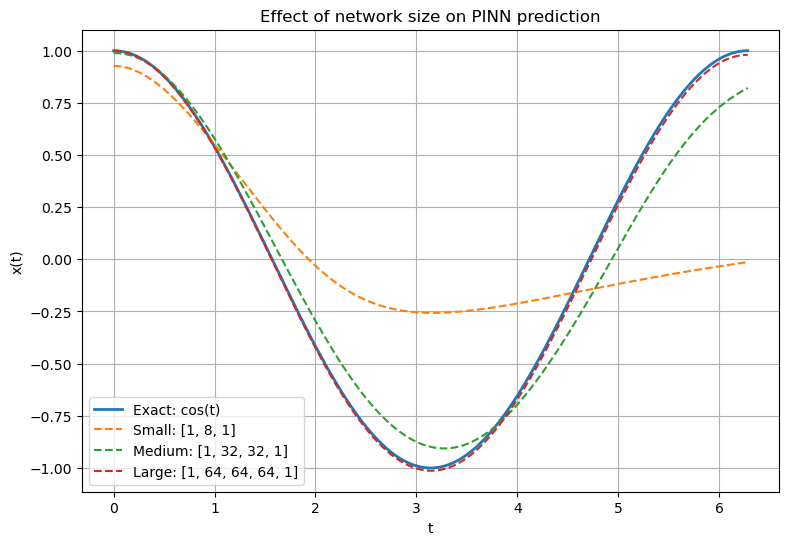

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def exact_solution(t):
    return np.cos(t)


class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        net = []
        for i in range(len(layers) - 2):
            net.append(nn.Linear(layers[i], layers[i+1]))
            net.append(nn.Tanh())
        net.append(nn.Linear(layers[-2], layers[-1]))
        self.model = nn.Sequential(*net)

    def forward(self, t):
        return self.model(t)


def pinn_loss(model, t_collocation):
    t_collocation.requires_grad_(True)
    x = model(t_collocation)

    dx_dt = torch.autograd.grad(
        x, t_collocation,
        grad_outputs=torch.ones_like(x),
        create_graph=True
    )[0]

    d2x_dt2 = torch.autograd.grad(
        dx_dt, t_collocation,
        grad_outputs=torch.ones_like(dx_dt),
        create_graph=True
    )[0]

    residual = d2x_dt2 + x
    loss_physics = torch.mean(residual**2)

    t0 = torch.tensor([[0.0]], dtype=torch.float32, device=device, requires_grad=True)
    x0 = model(t0)

    dx0_dt = torch.autograd.grad(
        x0, t0,
        grad_outputs=torch.ones_like(x0),
        create_graph=True
    )[0]

    loss_ic = (x0 - 1.0)**2 + (dx0_dt - 0.0)**2
    loss_total = loss_physics + loss_ic.mean()

    return loss_total


def train_model(layers, epochs=3000, lr=1e-3, n_collocation=200):
    model = PINN(layers).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        optimizer.zero_grad()
        t_collocation = torch.rand((n_collocation, 1), dtype=torch.float32, device=device) * (2 * np.pi)
        loss = pinn_loss(model, t_collocation)
        loss.backward()
        optimizer.step()

    return model


configs = {
    "Small: [1, 8, 1]": [1, 8, 1],
    "Medium: [1, 32, 32, 1]": [1, 32, 32, 1],
    "Large: [1, 64, 64, 64, 1]": [1, 64, 64, 64, 1]
}

t_test = np.linspace(0, 2*np.pi, 400).reshape(-1, 1)
t_tensor = torch.tensor(t_test, dtype=torch.float32, device=device)
x_exact = exact_solution(t_test)

plt.figure(figsize=(9, 6))
plt.plot(t_test, x_exact, linewidth=2, label="Exact: cos(t)")

for label, layers in configs.items():
    print(f"Training {label} ...")
    model = train_model(layers, epochs=3000)
    with torch.no_grad():
        x_pred = model(t_tensor).cpu().numpy()
    plt.plot(t_test, x_pred, "--", label=label)

plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Effect of network size on PINN prediction")
plt.legend()
plt.grid(True)
plt.show()